In [1]:
%%capture
pip install geopandas

In [2]:
import pandas as pd

In [5]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from shapely import wkt

In [7]:
df = pd.read_csv('Chicago_Crimes_2001_to_2017.csv')

/var/folders/06/r2dtrmr16vqfn420q_zltnpw0000gn/T/ipykernel_12090/3004442967.py:1: DtypeWarning: Columns (17,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Chicago_Crimes_2001_to_2017.csv')


In [8]:
df.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,F_Date,Time
0,879,4786321,HM399414,2004-01-01 00:01:00,082XX S COLES AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,...,06,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN,2004-01-01,00:01:00
1,2544,4676906,HM278933,2003-03-01 00:00:00,004XX W 42ND PL,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,...,26,1173974.0,1876757.0,2003.0,04/15/2016 08:55:02 AM,41.817229,-87.637328,"(41.817229156, -87.637328162)",2003-03-01,00:00:00
2,2919,4789749,HM402220,2004-06-20 11:00:00,025XX N KIMBALL AVE,1752,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,...,20,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN,2004-06-20,11:00:00
3,2927,4789765,HM402058,2004-12-30 20:00:00,045XX W MONTANA ST,0840,THEFT,FINANCIAL ID THEFT: OVER $300,OTHER,False,...,06,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN,2004-12-30,20:00:00
4,3302,4677901,HM275615,2003-05-01 01:00:00,111XX S NORMAL AVE,0841,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,...,06,1174948.0,1831051.0,2003.0,04/15/2016 08:55:02 AM,41.691785,-87.635116,"(41.691784636, -87.635115968)",2003-05-01,01:00:00


In [11]:
# 다섯가지 컬럼중 하나라도 NaN인 경우 행 제거
df = df.dropna(subset=['X Coordinate','Y Coordinate','Latitude', 'Longitude', 'Location'])

In [12]:
df.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,F_Date,Time
1,2544,4676906,HM278933,2003-03-01 00:00:00,004XX W 42ND PL,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,...,26,1173974.0,1876757.0,2003.0,04/15/2016 08:55:02 AM,41.817229,-87.637328,"(41.817229156, -87.637328162)",2003-03-01,00:00:00
4,3302,4677901,HM275615,2003-05-01 01:00:00,111XX S NORMAL AVE,0841,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,...,06,1174948.0,1831051.0,2003.0,04/15/2016 08:55:02 AM,41.691785,-87.635116,"(41.691784636, -87.635115968)",2003-05-01,01:00:00
6,3756,4791194,HM403711,2001-01-01 11:00:00,114XX S ST LAWRENCE AVE,0266,CRIM SEXUAL ASSAULT,PREDATORY,RESIDENCE,True,...,02,1182247.0,1829375.0,2001.0,08/29/2006 03:46:28 AM,41.68702,-87.608445,"(41.687020002, -87.60844523)",2001-01-01,11:00:00
7,4502,4679521,HM216293,2003-03-15 00:00:00,090XX S RACINE AVE,5007,OTHER OFFENSE,OTHER WEAPONS VIOLATION,RESIDENCE PORCH/HALLWAY,False,...,26,1169911.0,1844832.0,2003.0,04/15/2016 08:55:02 AM,41.729712,-87.653159,"(41.729712374, -87.653158513)",2003-03-15,00:00:00
9,4904,4680124,HM282389,2003-01-01 00:00:00,009XX S SPAULDING AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,...,06,1154521.0,1895755.0,2003.0,04/15/2016 08:55:02 AM,41.869772,-87.708180,"(41.869772159, -87.708180162)",2003-01-01,00:00:00


In [15]:
# Ward와 Community Area의 결측치 개수 확인
ward_missing_count = df['Ward'].isna().sum()
communityarea_missing_count = df['Community Area'].isna().sum()

print(f"Ward 결측치 개수: {ward_missing_count}")
print(f"Community Area 결측치 개수: {communityarea_missing_count}")

Ward 결측치 개수: 687154
Community Area 결측치 개수: 688830


In [17]:
df[df['Community Area'].isna() | df['Ward'].isna()][['Ward', 'Community Area', "Latitude", 'Longitude', 'Location']]


,Ward,Community Area,Latitude,Longitude,Location
1332,NaN,NaN,41.765282,-87.583655,"(41.765282432, -87.583654702)"
1450,NaN,NaN,41.865156,-87.713732,"(41.865156224, -87.71373199)"
1457,NaN,NaN,41.907251,-87.725224,"(41.907251262, -87.725224066)"
1468,NaN,NaN,41.748514,-87.664929,"(41.748514115, -87.664928601)"
1507,NaN,NaN,41.751253,-87.607096,"(41.751253211, -87.607096334)"
...,...,...,...,...,...
7043608,NaN,0.0,42.006074,-87.927365,"(42.006074109, -87.927364891)"
7199570,NaN,0.0,41.997193,-87.884464,"(41.997193305, -87.884463632)"
7223777,NaN,0.0,41.982993,-87.834219,"(41.982993154, -87.834218775)"
7417972,NaN,0.0,41.997336,-87.884466,"(41.997336014, -87.884466308)"


In [19]:
import os
print(os.getcwd())  # 현재 작업 디렉토리 출력
print(os.listdir("참고파일"))  # 참고파일 폴더 안 파일 목록 확인
print(os.path.exists("참고파일/Boundaries_-_Wards__2023-__20250325.csv"))
print(os.path.exists("참고파일/CommAreas_20250325.csv"))

/Users/sunwoo/멋쟁이사자처럼/project/finalproject
['Boundaries_-_Wards__2023-__20250325.csv', 'CommAreas_20250325.csv']
True
True


In [57]:
# 범죄 데이터의 위도, 경도 정보를 사용해 GeoDataFrame 생성
df['geometry'] = df.apply(lambda row: Point(row['Longitude'], row['Latitude']), axis=1)
crime_gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")  # WGS84 좌표계 설정

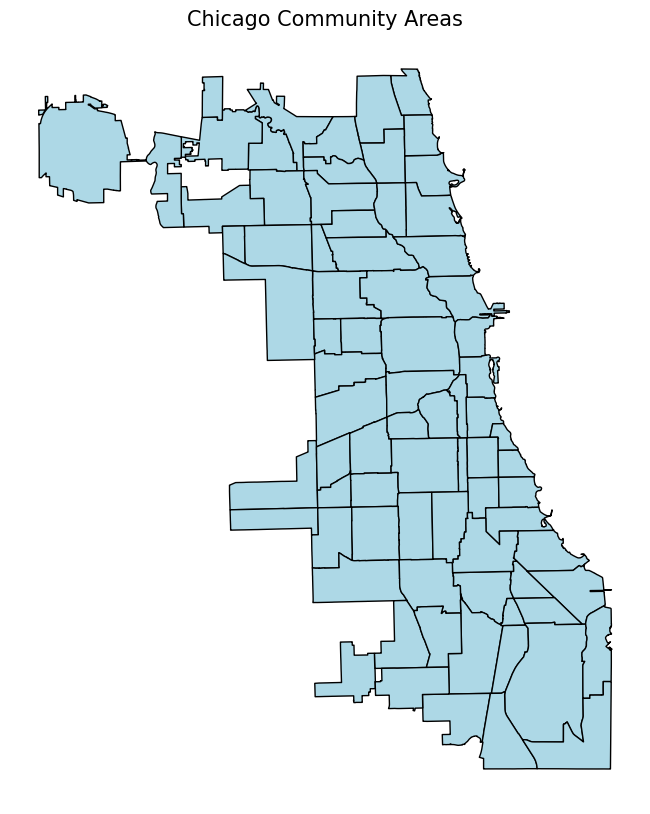

In [87]:
import matplotlib.pyplot as plt

# Community Area 시각화
fig, ax = plt.subplots(figsize=(10, 10))  # 크기 조정
community_areas_gdf.plot(ax=ax, color='lightblue', edgecolor='black')  # 커뮤니티 영역 시각화

# 제목 추가
ax.set_title("Chicago Community Areas", fontsize=15)

# 축 숨기기
ax.set_axis_off()

# 시각화 출력
plt.show()

In [58]:
# Community Area CSV 파일 불러오기 (the_geom을 WKT 형식으로 변환)
community_areas = pd.read_csv('참고파일/CommAreas_20250325.csv')  # Community Area 데이터 (CSV)
community_areas['geometry'] = community_areas['the_geom'].apply(wkt.loads)  # the_geom을 WKT로 변환
community_areas_gdf = gpd.GeoDataFrame(community_areas, geometry='geometry', crs="EPSG:4326")

In [59]:
# Ward CSV 파일 불러오기 (the_geom을 WKT 형식으로 변환)
wards = pd.read_csv('참고파일/Boundaries_-_Wards__2023-__20250325.csv')  # Ward 데이터 (CSV)
wards['geometry'] = wards['the_geom'].apply(wkt.loads)  # the_geom을 WKT로 변환
wards_gdf = gpd.GeoDataFrame(wards, geometry='geometry', crs="EPSG:4326")

In [31]:
wards_gdf.columns

Index(['Ward', 'the_geom', 'objectid', 'edit_date', 'ward_id', 'globalid',
       'st_area_sh', 'st_length_', 'geometry'],
      dtype='object')

In [33]:
wards_gdf.head()

,Ward,the_geom,objectid,edit_date,ward_id,globalid,st_area_sh,st_length_,geometry
0,1,MULTIPOLYGON (((-87.68777205374418 41.92858465...,51,06/01/2022,1,{DB2A2A7D-FAF1-42A4-B061-AE18C31A80BB},6.589346e+07,61878.821587,"MULTIPOLYGON (((-87.68777 41.92858, -87.68776 ..."
1,2,MULTIPOLYGON (((-87.62517201063106 41.90399836...,52,06/01/2022,2,{88F300F6-D6DF-4337-8DE3-0C2D27A5B338},3.128511e+07,74175.949239,"MULTIPOLYGON (((-87.62517 41.904, -87.625 41.9..."
2,5,MULTIPOLYGON (((-87.56030308695986 41.76635735...,55,06/01/2022,5,{0A109A41-9DED-47D7-934E-1EA1CC7EE025},1.120803e+08,88207.690241,"MULTIPOLYGON (((-87.5603 41.76636, -87.56058 4..."
3,6,MULTIPOLYGON (((-87.61794321281114 41.77292489...,56,06/01/2022,6,{FD74A999-4BBA-4CE3-BEBB-CC76423037E8},1.392022e+08,80779.851890,"MULTIPOLYGON (((-87.61794 41.77292, -87.61786 ..."
4,7,MULTIPOLYGON (((-87.54393108740227 41.76029599...,57,06/01/2022,7,{279FCBD9-EA0D-4FFC-A8CA-EDA2676C0721},1.414924e+08,98906.567862,"MULTIPOLYGON (((-87.54393 41.7603, -87.5437 41..."


In [61]:
# 6. 범죄 데이터의 좌표가 어느 Ward에 속하는지 Spatial Join
crime_with_ward = gpd.sjoin(crime_gdf, wards_gdf[['Ward', 'geometry']], how='left', predicate='within')

In [36]:
community_areas_gdf.columns

Index(['the_geom', 'PERIMETER', 'AREA', 'COMAREA_', 'COMAREA_ID', 'AREA_NUMBE',
       'COMMUNITY', 'AREA_NUM_1', 'SHAPE_AREA', 'SHAPE_LEN', 'geometry'],
      dtype='object')

In [37]:
community_areas_gdf.head()

,the_geom,PERIMETER,AREA,COMAREA_,COMAREA_ID,AREA_NUMBE,COMMUNITY,AREA_NUM_1,SHAPE_AREA,SHAPE_LEN,geometry
0,MULTIPOLYGON (((-87.60914087617894 41.84469250...,0,0,0,0,35,DOUGLAS,35,4.600462e+07,31027.054510,"MULTIPOLYGON (((-87.60914 41.84469, -87.60915 ..."
1,MULTIPOLYGON (((-87.59215283879394 41.81692934...,0,0,0,0,36,OAKLAND,36,1.691396e+07,19565.506153,"MULTIPOLYGON (((-87.59215 41.81693, -87.59231 ..."
2,MULTIPOLYGON (((-87.62879823733725 41.80189303...,0,0,0,0,37,FULLER PARK,37,1.991670e+07,25339.089750,"MULTIPOLYGON (((-87.6288 41.80189, -87.62879 4..."
3,MULTIPOLYGON (((-87.6067081256125 41.816813770...,0,0,0,0,38,GRAND BOULEVARD,38,4.849250e+07,28196.837157,"MULTIPOLYGON (((-87.60671 41.81681, -87.6067 4..."
4,MULTIPOLYGON (((-87.59215283879394 41.81692934...,0,0,0,0,39,KENWOOD,39,2.907174e+07,23325.167906,"MULTIPOLYGON (((-87.59215 41.81693, -87.59215 ..."


In [62]:
# 7. 범죄 데이터의 좌표가 어느 Community Area에 속하는지 Spatial Join
crime_with_community = gpd.sjoin(
    crime_with_ward,
    community_areas_gdf[['AREA_NUMBE', 'geometry']],  # 'COMMUNITY' 대신 'AREA_NUMBE' 사용
    how='left',
    predicate='within',
    lsuffix='_ward',
    rsuffix='_community'
)

In [42]:
crime_with_community.columns

Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward_left', 'Community Area',
       'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On',
       'Latitude', 'Longitude', 'Location', 'F_Date', 'Time', 'geometry',
       'index_right', 'Ward_right', 'index__community', 'AREA_NUMBE'],
      dtype='object')

In [45]:
crime_with_community.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,Latitude,Longitude,Location,F_Date,Time,geometry,index_right,Ward_right,index__community,AREA_NUMBE
1,2544,4676906,HM278933,2003-03-01 00:00:00,004XX W 42ND PL,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,...,41.817229,-87.637328,"(41.817229156, -87.637328162)",2003-03-01,00:00:00,POINT (-87.63733 41.81723),6.0,11.0,58.0,61.0
4,3302,4677901,HM275615,2003-05-01 01:00:00,111XX S NORMAL AVE,0841,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,...,41.691785,-87.635116,"(41.691784636, -87.635115968)",2003-05-01,01:00:00,POINT (-87.63512 41.69178),20.0,21.0,46.0,49.0
6,3756,4791194,HM403711,2001-01-01 11:00:00,114XX S ST LAWRENCE AVE,0266,CRIM SEXUAL ASSAULT,PREDATORY,RESIDENCE,True,...,41.68702,-87.608445,"(41.687020002, -87.60844523)",2001-01-01,11:00:00,POINT (-87.60845 41.68702),10.0,9.0,48.0,50.0
7,4502,4679521,HM216293,2003-03-15 00:00:00,090XX S RACINE AVE,5007,OTHER OFFENSE,OTHER WEAPONS VIOLATION,RESIDENCE PORCH/HALLWAY,False,...,41.729712,-87.653159,"(41.729712374, -87.653158513)",2003-03-15,00:00:00,POINT (-87.65316 41.72971),20.0,21.0,71.0,73.0
9,4904,4680124,HM282389,2003-01-01 00:00:00,009XX S SPAULDING AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,...,41.869772,-87.708180,"(41.869772159, -87.708180162)",2003-01-01,00:00:00,POINT (-87.70818 41.86977),23.0,24.0,29.0,29.0


In [63]:
crime_with_community = crime_with_community.rename(columns={'Ward_left': 'Ward'})

In [64]:
# 8. 'Ward'와 'Community Area' 결측치 채우기
# 'Community Area' 결측치 처리
crime_with_community['Community Area'] = crime_with_community['Community Area'].fillna(crime_with_community['AREA_NUMBE'])
# 'Ward' 결측치 처리
crime_with_community['Ward'] = crime_with_community['Ward'].fillna(crime_with_community['Ward'])

In [65]:
# 10. 결측치 확인
print(crime_with_community[['Ward', 'Community Area']].isna().sum())  # 결측치 확인

Ward              687154
Community Area       482
dtype: int64


In [75]:
# ward 채워지지 않음
# 'Ward' 컬럼이 결측인 경우, 'Ward_right' 컬럼으로 채우기
crime_with_community['Ward'] = crime_with_community['Ward'].fillna(crime_with_community['Ward_right'])

In [79]:
# 10. 결측치 확인
print(crime_with_community[['Ward', 'Community Area']].isna().sum())  # 결측치 확인

Ward              606
Community Area    482
dtype: int64


In [83]:
# 11. 결과를 CSV로 저장
crime_with_community.to_csv('chicago_crime_data_with_ward_community2.csv', index=False)